# Chapter 4 — Electricity Finds Deformation
### *Modern Strain Gage Technology* — Companion Notebook

*Stretch a metal wire and its resistance changes — a whisper of a signal that the Wheatstone bridge turns into a number you can trust.*

**Companion notebook to Chapter 4 — Electricity Finds Deformation.**

The Wheatstone bridge was published in 1843 — almost a century before the first resistance strain gage. Charles Wheatstone's circuit was designed to measure unknown resistances with extreme precision by balancing four resistors until no current flowed through a sensitive galvanometer. Strain gage measurement appropriates this circuit for a different purpose: one arm of the bridge is a gage whose resistance changes proportionally to deformation, and that change unbalances the bridge and produces a measurable output voltage.

The linear approximation V_out ≈ V_ex · GF · ε / 4 is what every data-acquisition system implements, and it is adequate for most structural testing. But the exact expression — which accounts for the changing current distribution as the bridge unbalances — is nonlinear, and the error between the two grows with strain. At 1000 με the error is about 0.1%; at 10,000 με it reaches 1%; at 100,000 με it is nearly 9%. For high-strain applications — plasticity studies, crash testing, impact events — this correction must be applied, or the instrument will consistently understate the true strain.

The second figure uses the Micro-Measurements TN-507-1 formulation to make the correction magnitude concrete. Understanding when the nonlinearity matters — and how to correct for it — is part of understanding what the Wheatstone bridge circuit actually delivers.

**This notebook demonstrates:**
1. Wheatstone bridge output vs. ΔR/R — exact formula vs. linear approximation, with per-reading nonlinearity error (right panel)
2. Bridge nonlinearity vs. strain — log-log plot for quarter-bridge and Poisson half-bridge, with correction table comparing true strain to indicated strain

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures for this chapter are written here; the book \includegraphics these exact files.
OUT_DIR = Path("../src/media/ch04")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Wheatstone Bridge Output vs. Resistance Change

The Wheatstone bridge is balanced when R₁/R₂ = R₄/R₃ — at balance, the output voltage is zero regardless of excitation voltage. Any resistance change in one arm unbalances the bridge and produces an output. For a quarter-bridge (one active gage, three fixed equal resistors), the exact output when one arm changes by ΔR is:

V_out = V_ex · [(R+ΔR)/((R+ΔR)+R) − R/(R+R)] = V_ex · ΔR/(4R + 2ΔR)

The linear approximation V_out ≈ V_ex · (ΔR/R) / 4 holds well when ΔR/R is small — which it is for elastic strain in most metals, where ΔR/R = GF · ε ≈ 0.002 at 1000 με. The right panel in this figure shows the per-reading error between the exact and linear expressions. For tension (ΔR/R > 0), the exact output is slightly less than the linear approximation — the instrument underreads. For compression (ΔR/R < 0), the exact output has slightly greater magnitude — the instrument overreads. The asymmetry is a second-order effect, negligible at low strains and meaningful only at high strains where the bridge current distribution shifts significantly.

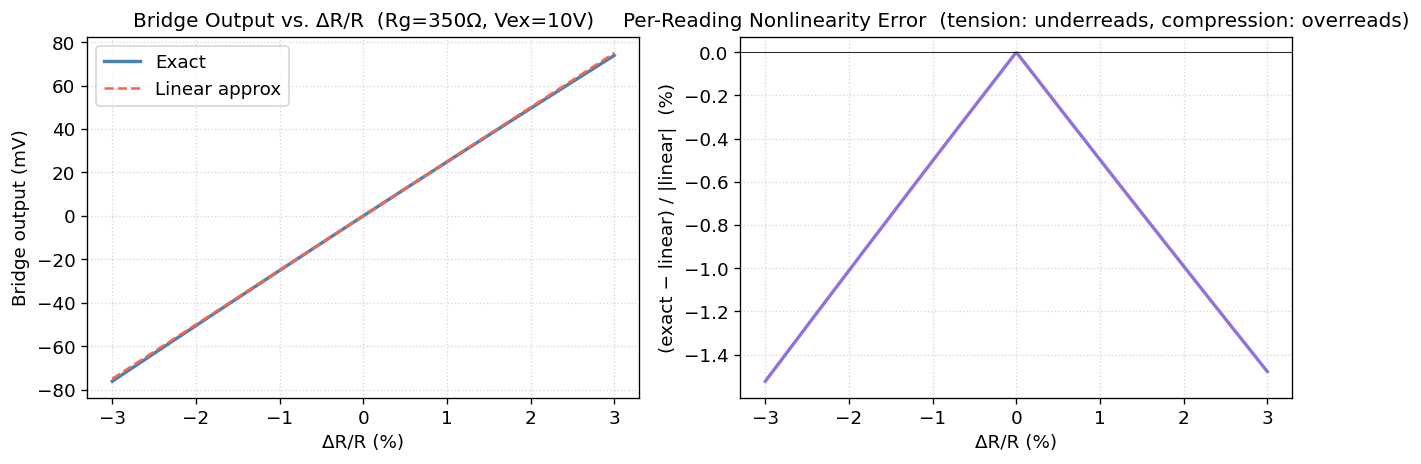

In [2]:
# Wheatstone bridge, general four-arm form.
# Arms: R1 (top-left), R2 (bottom-left), R3 (top-right), R4 (bottom-right).
def bridge_output(R1, R2, R3, R4, Vex):
    """Bridge output voltage for arbitrary arm resistances.

    Vout = Vex * (R3/(R3+R4) - R2/(R1+R2)); zero when R1/R2 = R4/R3 (balance).
    Any argument may be a NumPy array (values broadcast).
    """
    return Vex * (R3 / (R3 + R4) - R2 / (R1 + R2))

R_GAGE  = 350.0   # baseline gage resistance (Ω)
V_EX    = 10.0    # excitation voltage (V)
DRR_MAX = 0.03    # sweep fractional resistance change, ±3%
N_PTS   = 400

# Sweep fractional resistance change ΔR/R in one active arm (arm R3).
dRR = np.linspace(-DRR_MAX, DRR_MAX, N_PTS)          # dimensionless
Vout_exact  = bridge_output(R_GAGE, R_GAGE, R_GAGE * (1 + dRR), R_GAGE, V_EX)
Vout_linear = V_EX * dRR / 4.0                        # Vout ≈ (Vex/4)·(ΔR/R)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(dRR * 100, Vout_exact * 1000, 'steelblue', lw=2, label='Exact')
axes[0].plot(dRR * 100, Vout_linear * 1000, 'tomato', lw=1.5, linestyle='--', label='Linear approx')
axes[0].set_xlabel('ΔR/R (%)'); axes[0].set_ylabel('Bridge output (mV)')
axes[0].set_title(f'Bridge Output vs. ΔR/R  (Rg={R_GAGE:.0f}Ω, Vex={V_EX:.0f}V)')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.5)

# Per-reading nonlinearity: (exact − linear) relative to |linear|.
#   Tension (ΔR/R > 0): exact < linear        → instrument underreads.
#   Compression (ΔR/R < 0): |exact| > |linear| → instrument overreads in magnitude.
nonlin_pct = 100 * (Vout_exact - Vout_linear) / (np.abs(Vout_linear) + 1e-12)
axes[1].plot(dRR * 100, nonlin_pct, 'mediumpurple', lw=2)
axes[1].set_xlabel('ΔR/R (%)'); axes[1].set_ylabel('(exact − linear) / |linear|  (%)')
axes[1].set_title('Per-Reading Nonlinearity Error  (tension: underreads, compression: overreads)')
axes[1].axhline(0, color='black', lw=0.5); axes[1].grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig04_nb1_bridge_output_vs_resistance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 2 — Bridge Nonlinearity vs. Strain

The quarter-bridge linear approximation $V_{out}/V_{ex} = \frac{1}{4}GF\varepsilon$ understates the true output at high strains. Expressed as a fraction of the reading, the nonlinearity is:

$$\eta = \frac{GF\,\varepsilon}{2 + GF\,\varepsilon}$$

where $\varepsilon$ is the true (absolute) strain. In words: the error grows in proportion to $GF\,\varepsilon = \Delta R/R$, so it is negligible for elastic metal strains and only becomes appreciable in the percent-strain regime.

**Rule of thumb**: error % $\approx$ strain %. At 1000 με: 0.1 %; at 10 000 με: 1 %; at 100 000 με: ~9 %.

Bending half-bridges and full-bridge bending/torsion circuits are **exactly linear** — their equal-and-opposite arm arrangement keeps branch currents constant.

When correction is needed, the indicated strain $\varepsilon_i$ (from the linear model) converts to true strain by inverting the relation above:

$$\varepsilon = \frac{2\,\varepsilon_i}{2 - GF\,\varepsilon_i}$$

*(After Micro-Measurements Tech Note TN-507-1)*

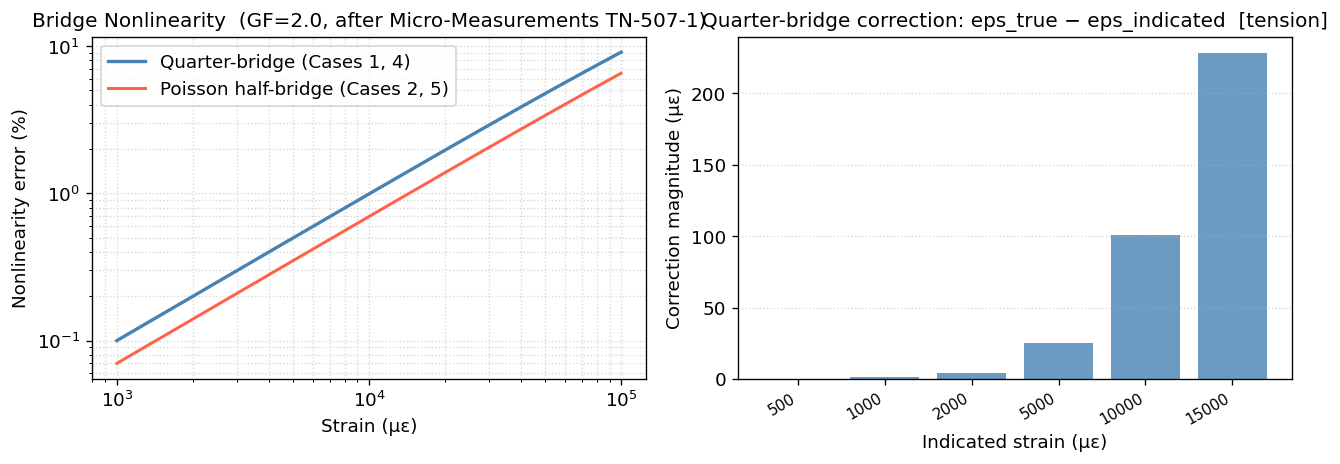

Quarter-bridge correction table  (GF=2.0, tension):
   ei (ue)   eta (%)    eps_true    error (ue)
       500     0.050         500             0
      1000     0.100        1001             1
      2000     0.200        2004             4
      5000     0.498        5025            25
     10000     0.990       10101           101
     15000     1.478       15228           228


In [3]:
# Bridge nonlinearity vs. strain — TN-507-1 Fig. 2 style
GF    = 2.0     # gage factor (typical constantan foil)
NU    = 0.30    # Poisson's ratio (typical structural metal)
MICRO = 1e-6    # microstrain → absolute strain


def quarter_bridge_nonlinearity(eps_true, gf=GF):
    """Fractional quarter-bridge nonlinearity η = GF·ε / (2 + GF·ε).

    eps_true is absolute strain (not microstrain). Returns a dimensionless fraction
    (multiply by 100 for percent). Covers TN-507-1 Cases 1 and 4.
    """
    dRR = gf * eps_true
    return dRR / (2 + dRR)


def poisson_half_bridge_nonlinearity(eps_true, gf=GF, nu=NU):
    """Fractional nonlinearity for a Poisson half-bridge (Cases 2, 5).

    One active axial gage plus one transverse (Poisson) gage; the effective
    sensitivity scales by (1 − ν). eps_true is absolute strain.
    """
    dRR = gf * (1 - nu) * eps_true
    return dRR / (2 + dRR)


def true_strain(eps_indicated, gf=GF):
    """Correct a linear-model indicated strain back to true strain.

    ε = 2·ε_i / (2 − GF·ε_i); the exact inverse of the quarter-bridge nonlinearity.
    eps_indicated is absolute strain.
    """
    return 2 * eps_indicated / (2 - gf * eps_indicated)


eps_ue = np.logspace(3, 5, 400)                       # 1000 to 100 000 με
eta_q  = quarter_bridge_nonlinearity(eps_ue * MICRO)  # quarter-bridge (Cases 1, 4)
eta_ph = poisson_half_bridge_nonlinearity(eps_ue * MICRO)  # Poisson half-bridge (Cases 2, 5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(eps_ue, eta_q * 100, 'steelblue', lw=2, label='Quarter-bridge (Cases 1, 4)')
axes[0].loglog(eps_ue, eta_ph * 100, 'tomato', lw=1.8, label='Poisson half-bridge (Cases 2, 5)')
axes[0].set_xlabel('Strain (με)')
axes[0].set_ylabel('Nonlinearity error (%)')
axes[0].set_title('Bridge Nonlinearity  (GF=2.0, after Micro-Measurements TN-507-1)')
axes[0].legend()
axes[0].grid(True, which='both', linestyle=':', alpha=0.5)

# Correction table — quarter-bridge tension.
ei_vals  = [500, 1000, 2000, 5000, 10000, 15000]              # indicated strain (με)
eps_corr = [true_strain(ei * MICRO) / MICRO for ei in ei_vals]  # true strain (με)
errs     = [et - ei for et, ei in zip(eps_corr, ei_vals)]      # correction (με)
axes[1].bar(range(len(ei_vals)), [abs(e) for e in errs], color='steelblue', alpha=0.8)
axes[1].set_xticks(range(len(ei_vals)))
axes[1].set_xticklabels([str(ei) for ei in ei_vals], rotation=30, ha='right', fontsize=9)
axes[1].set_xlabel('Indicated strain (με)')
axes[1].set_ylabel('Correction magnitude (με)')
axes[1].set_title('Quarter-bridge correction: eps_true − eps_indicated  [tension]')
axes[1].grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig04_nb2_bridge_nonlinearity.png', bbox_inches='tight', dpi=150)
plt.show()

print("Quarter-bridge correction table  (GF=2.0, tension):")
print(f"{'ei (ue)':>10}  {'eta (%)':>8}  {'eps_true':>10}  {'error (ue)':>12}")
for ei, et, err in zip(ei_vals, eps_corr, errs):
    eta_i = quarter_bridge_nonlinearity(ei * MICRO) * 100
    print(f"{ei:>10}  {eta_i:>8.3f}  {et:>10.0f}  {err:>12.0f}")

---
## Where to take this next

- **Add lead-wire resistance.** Extend `bridge_output` to include the resistance of the gage's lead wires in series with the active arm, then plot how a long two-wire hookup desensitizes the bridge — and show how the three-wire quarter-bridge cancels most of that error.
- **Sweep the gage factor and Poisson ratio.** Regenerate the nonlinearity plot for GF from 2.0 (constantan) up to ~140 (silicon piezoresistive), and for several ν values, to see how semiconductor gages push the correction into the everyday measurement range rather than the percent-strain regime.
- **Close the loop with a simulated measurement.** Pick a true strain, compute the exact bridge output, back it out through the *linear* model to get an indicated strain, then recover the true value with `true_strain()` — verifying the correction round-trips to within numerical precision across the full 0–100,000 με range.